In [ ]:
include("CRD_STA.jl")
using Plots
using Arpack
using SparseArrays

In [115]:
N_cheb = 99
Mr = 0.1
gamma = 1.4
sigma = 0.72
Ro = 1
Co = 0
Tw = 1
R = 27.4
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T

100×1 Matrix{Float64}:
 1.3888888889385158
 1.3888905302191146
 1.3888954460696825
 1.3889036124730143
 1.3889149892577193
 1.3889295198917715
 1.3889471312088515
 1.3889677330830965
 1.3889912180725037
 1.3890174610561674
 ⋮
 1.3888889742105857
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176

In [119]:
al = 0.487
be = 0.115
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,1,be,N_cheb,1,0)
B0,B1 = TimeMode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,1,be,N_cheb,Ro,Co)
# B0 = sparse(B0)
# B1 = sparse(B1)
# val,vec = eigs(B0,-B1,nev=3,sigma=0,tol = 1e-8,maxiter = 10000)
# val
c = eigen(B0,-B1)
val = c.values;  

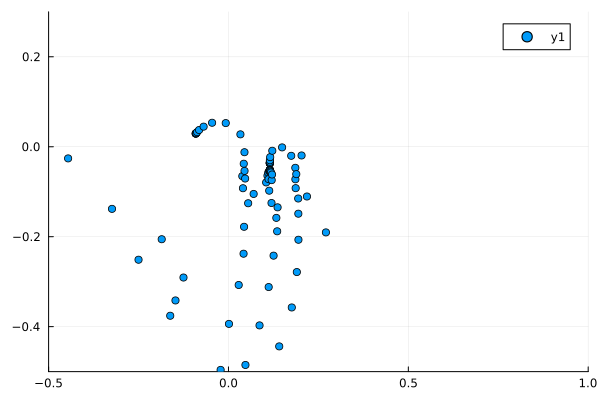

In [120]:
scatter(real(val),imag(val),xlims=[-0.5,1],ylims=[-0.5,0.3])

In [121]:
A0+A1+A2-B0-B1

490×490 Matrix{ComplexF64}:
 0.0+27.4im  0.0+0.0im      0.0+0.0im      …          0.0+0.0im
 0.0+0.0im   0.0+27.3999im  0.0+0.0im                 0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+27.3997im             0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im                 0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im                 0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im      …          0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im                 0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im                 0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im                 0.0+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im                 0.0+0.0im
    ⋮                                      ⋱  
 0.0+0.0im   0.0+0.0im      0.0+0.0im          -0.0110738+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im          0.00879021+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im         -0.00677076+0.0im
 0.0+0.0im   0.0+0.0im      0.0+0.0im          0.00501731+0.0im
 0.0+0.0im   0.0+0.0im      0

In [85]:
function TimeMode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,alpha_given,be,N_cheb,Ro,Co)    
    # 使用 .* I(N_cheb + 1) 替代 diagm
    
    # B0矩阵 - 不含ω的项
    B0_11 = rho .* I(N_cheb + 1)
    
    B0_12 = im * be * R * rho .* I(N_cheb + 1)
    
    B0_13 = R * (rho .* (D * rho) .* I(N_cheb + 1) + rho .* I(N_cheb + 1) * D)
    
    B0_14 = (im * R * be * G .* I(N_cheb + 1)) + 
            (2 * F .* I(N_cheb + 1)) + 
            (rho .* (D * H) .* I(N_cheb + 1)) + 
            (rho .* I(N_cheb + 1) * H .* I(N_cheb + 1) * D) + 
            (alpha_given * im * R * F .* I(N_cheb + 1))
    
    B0_15 = zeros(N_cheb + 1, N_cheb + 1)

    B0_21 = (im * R * be * (rho .* G) .* I(N_cheb + 1)) + 
            (Ro * (rho .* F) .* I(N_cheb + 1)) + 
            (be^2 * T .* I(N_cheb + 1)) + 
            (Ro * rho.^2 .* I(N_cheb + 1) * H .* I(N_cheb + 1) * D) - 
            (rho .* I(N_cheb + 1) * D2) + 
            (alpha_given * im * R * (rho .* F) .* I(N_cheb + 1)) + 
            (alpha_given^2 * (lam .+ 2 * T) .* I(N_cheb + 1))
    
    B0_22 = (-(rho .* (2*Ro * G .+ Co)) .* I(N_cheb + 1)) + 
            (alpha_given * be * (lam .+ T) .* I(N_cheb + 1))
    
    B0_23 = (R * (rho.^2 .* (D*F)) .* I(N_cheb + 1)) + 
            (alpha_given * (-im * ((rho .* (D*T)) .* I(N_cheb + 1) + 
                                  (ones(N_cheb+1) .+ lam .* rho) .* I(N_cheb + 1) * D)))
    
    B0_24 = ((rho .* (D2 * F)) .* I(N_cheb + 1)) + 
            (alpha_given * im * R * (gamma*Ma^2)^(-1) * T .* I(N_cheb + 1))
    
    B0_25 = (-(rho .* (D * rho .* (D * F) + rho .* (D2 * F))) .* I(N_cheb + 1)) - 
            (rho.^2 .* I(N_cheb + 1) * (D*F) .* I(N_cheb + 1) * D) + 
            (alpha_given * im * R * (gamma*Ma^2)^(-1) * rho .* I(N_cheb + 1))

    B0_31 = ((rho .* (2 * Ro * G .+ Co)) .* I(N_cheb + 1)) + 
            (alpha_given * be * (lam .+ T) .* I(N_cheb + 1))
    
    B0_32 = (im * R * be * (rho .* G) .* I(N_cheb + 1)) + 
            (Ro * (rho .* F) .* I(N_cheb + 1)) + 
            (be^2 * (lam .+ 2 * T) .* I(N_cheb + 1)) + 
            (Ro * rho.^2 .* I(N_cheb + 1) * H .* I(N_cheb + 1) * D) - 
            (rho .* I(N_cheb + 1) * D2) + 
            (alpha_given * im * R * (rho .* F) .* I(N_cheb + 1)) + 
            (alpha_given^2 * T .* I(N_cheb + 1))
    
    B0_33 = (R * (rho.^2 .* (D*G)) .* I(N_cheb + 1)) - 
            (im * be * ((rho .* (D*T)) .* I(N_cheb + 1) + 
                       (ones(N_cheb+1) .+ lam .* rho) .* I(N_cheb + 1) * D))
    
    B0_34 = ((F .* (2 * Ro * G .+ Co)) .* I(N_cheb + 1)) + 
            (Ro * rho .* I(N_cheb + 1) * (H .* (D*G)) .* I(N_cheb + 1)) + 
            (im * be * R * (gamma*Ma^2)^(-1) * T .* I(N_cheb + 1))
    
    B0_35 = (-(rho .* (D * rho .* (D * G) + rho .* (D2 * G))) .* I(N_cheb + 1)) - 
            (rho.^2 .* I(N_cheb + 1) * (D*G) .* I(N_cheb + 1) * D) + 
            (im * be * R * (gamma*Ma^2)^(-1) * rho .* I(N_cheb + 1))

    B0_41 = (alpha_given * (-im * ((rho .* (D*lam)) .* I(N_cheb + 1) + 
                                  (ones(N_cheb+1) .+ lam .* rho) .* I(N_cheb + 1) * D)))
    
    B0_42 = -im * be * ((rho .* (D*lam)) .* I(N_cheb + 1) + 
                       (ones(N_cheb+1) .+ lam .* rho) .* I(N_cheb + 1) * D)
    
    B0_43 = (im * R * be * (rho .* G) .* I(N_cheb + 1)) + 
            (Ro * rho.^2 .* I(N_cheb + 1) * ((D*H) .* I(N_cheb + 1) + H .* I(N_cheb + 1) * D)) - 
            ((rho .* (2 * ones(N_cheb+1) .+ lam .* rho)) .* I(N_cheb + 1) * D2) + 
            (be^2 * T .* I(N_cheb + 1)) + 
            (alpha_given * im * R * (rho .* F) .* I(N_cheb + 1)) + 
            (alpha_given^2 * T .* I(N_cheb + 1))
    
    B0_44 = (gamma*Ma^2)^(-1) * R * rho .* I(N_cheb + 1) * ((D*T) .* I(N_cheb + 1) + T .* I(N_cheb + 1) * D)
    
    B0_45 = (-im * (rho .* (be .* (D*G))) .* I(N_cheb + 1)) + 
            ((gamma*Ma^2)^(-1) * R * rho .* I(N_cheb + 1) * ((D*rho) .* I(N_cheb + 1) + rho .* I(N_cheb + 1) * D)) + 
            (alpha_given * (-im * (rho .* (D*F)) .* I(N_cheb + 1)))

    B0_51 = -2 * (gamma - 1) * Ma^2 * rho .* I(N_cheb + 1) * (D*F) .* I(N_cheb + 1) * D
    
    B0_52 = -2 * (gamma - 1) * Ma^2 * rho .* I(N_cheb + 1) * (D*G) .* I(N_cheb + 1) * D
    
    B0_53 = (-2 * im * (gamma - 1) * Ma^2 * (be .* (D*G)) .* I(N_cheb + 1)) + 
            (R * (rho.^2 .* (D*T)) .* I(N_cheb + 1)) + 
            (alpha_given * (-2 * im * (gamma - 1) * Ma^2 * (D * F) .* I(N_cheb + 1)))
    
    B0_54 = ((rho .* H .* (D*T)) .* I(N_cheb + 1)) - 
            ((gamma - 1) * gamma^(-1) * (im * R * be * (G .* T) .* I(N_cheb + 1) + 
                                        (rho .* H .* (D*T)) .* I(N_cheb + 1) + 
                                        rho .* I(N_cheb + 1) * H .* I(N_cheb + 1) * T .* I(N_cheb + 1) * D)) + 
            (alpha_given * (-(gamma - 1) * gamma^(-1) * im * R * (F .* T) .* I(N_cheb + 1)))
    
    B0_55 = (im * R * be * (rho .* G) .* I(N_cheb + 1)) + 
            (be^2 * kappa .* I(N_cheb + 1)) + 
            (rho.^2 .* I(N_cheb + 1) * H .* I(N_cheb + 1) * D - (rho.^2 .* kappa) .* I(N_cheb + 1) * D2) + 
            (sigma^(-1) * (-rho .* I(N_cheb + 1) * (((D*rho) .* (D*T)) .* I(N_cheb + 1) + 
                                                   (rho .* (D2 * T)) .* I(N_cheb + 1) - 
                                                   (rho .* (D*T)) .* I(N_cheb + 1) * D))) + 
            (-(gamma - 1) * Ma^2 * (rho.^2 .* ((D*F).^2 + (D*G).^2)) .* I(N_cheb + 1)) - 
            ((gamma - 1) * gamma^(-1) * (im * R * be * (G .* rho) .* I(N_cheb + 1) + 
                                        (rho .* H .* (D*rho)) .* I(N_cheb + 1) + 
                                        rho .* I(N_cheb + 1) * H .* I(N_cheb + 1) * rho .* I(N_cheb + 1) * D)) + 
            (alpha_given * (im * R * (rho .* F) .* I(N_cheb + 1) - 
                           (gamma - 1) * gamma^(-1) * im * R * (F .* rho) .* I(N_cheb + 1))) + 
            (alpha_given^2 * kappa .* I(N_cheb + 1))

    # B1矩阵 - ω的系数矩阵
    B1_11 = zeros(N_cheb + 1, N_cheb + 1)
    B1_12 = zeros(N_cheb + 1, N_cheb + 1)
    B1_13 = zeros(N_cheb + 1, N_cheb + 1)
    B1_14 = -im * R * I(N_cheb + 1)
    B1_15 = zeros(N_cheb + 1, N_cheb + 1)

    B1_21 = -im * R * rho .* I(N_cheb + 1)
    B1_22 = zeros(N_cheb + 1, N_cheb + 1)
    B1_23 = zeros(N_cheb + 1, N_cheb + 1)
    B1_24 = zeros(N_cheb + 1, N_cheb + 1)
    B1_25 = zeros(N_cheb + 1, N_cheb + 1)

    B1_31 = zeros(N_cheb + 1, N_cheb + 1)
    B1_32 = -im * R * rho .* I(N_cheb + 1)
    B1_33 = zeros(N_cheb + 1, N_cheb + 1)
    B1_34 = zeros(N_cheb + 1, N_cheb + 1)
    B1_35 = zeros(N_cheb + 1, N_cheb + 1)

    B1_41 = zeros(N_cheb + 1, N_cheb + 1)
    B1_42 = zeros(N_cheb + 1, N_cheb + 1)
    B1_43 = -im * R * rho .* I(N_cheb + 1)
    B1_44 = zeros(N_cheb + 1, N_cheb + 1)
    B1_45 = zeros(N_cheb + 1, N_cheb + 1)

    B1_51 = zeros(N_cheb + 1, N_cheb + 1)
    B1_52 = zeros(N_cheb + 1, N_cheb + 1)
    B1_53 = zeros(N_cheb + 1, N_cheb + 1)
    B1_54 = (gamma - 1) * gamma^(-1) * im * R * T .* I(N_cheb + 1)
    B1_55 = (-im * R * rho .* I(N_cheb + 1)) + 
            ((gamma - 1) * gamma^(-1) * im * R * rho .* I(N_cheb + 1))

    # 组装完整矩阵
    B0 = [B0_11 B0_12 B0_13 B0_14 B0_15;
          B0_21 B0_22 B0_23 B0_24 B0_25;
          B0_31 B0_32 B0_33 B0_34 B0_35;
          B0_41 B0_42 B0_43 B0_44 B0_45;
          B0_51 B0_52 B0_53 B0_54 B0_55]

    B1 = [B1_11 B1_12 B1_13 B1_14 B1_15;
          B1_21 B1_22 B1_23 B1_24 B1_25;
          B1_31 B1_32 B1_33 B1_34 B1_35;
          B1_41 B1_42 B1_43 B1_44 B1_45;
          B1_51 B1_52 B1_53 B1_54 B1_55]
    B0 = B0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    B1 = B1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    return B0, B1
end


TimeMode_BEK (generic function with 1 method)

In [ ]:
function rayleigh_quotient_iteration(A, B, sigma; q0=rand(size(A, 1), 1))

    flg = true
    while flg
        sigma0 = sigma[1]+ 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end

    end

      return sigma, q0
end

rayleigh_quotient_iteration (generic function with 1 method)